# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [2]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45993 non-null  int64 
 1   article_id  45993 non-null  int64 
 2   title       45993 non-null  object
 3   email       45976 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.4+ MB


In [3]:
print(f"Number of Null email values is: ")
print(df['email'].isna().sum())

Number of Null email values is: 
17


In [4]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016,why you should master r (even if it might even...,NaN
29758,30157,1393,the nurse assignment problem,NaN
29759,30158,20,working interactively with rstudio and noteboo...,NaN
29760,30159,1174,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62,data visualization: the importance of excludin...,NaN
35264,36016,224,"using apply, sapply, lapply in r",NaN
35276,36029,961,beyond parallelize and collect,NaN
35277,36030,268,sector correlations shiny app,NaN
35278,36031,268,sector correlations shiny app,NaN
35279,36032,268,sector correlations shiny app,NaN


In [5]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna("unknown_user")

In [6]:
# Check if no more NaNs 
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [7]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_interact_counts = df.groupby('email')['article_id'].count()
stats = user_interact_counts.describe()
print(stats)

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64


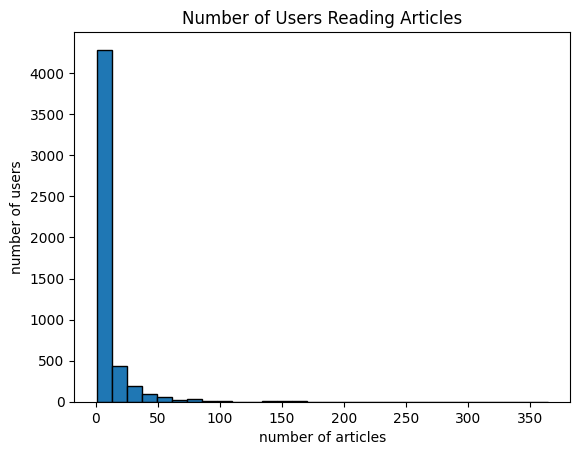

In [8]:
# Create a plot of the number of articles read by each user
plt.hist(user_interact_counts, bins=30, edgecolor='black')

plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

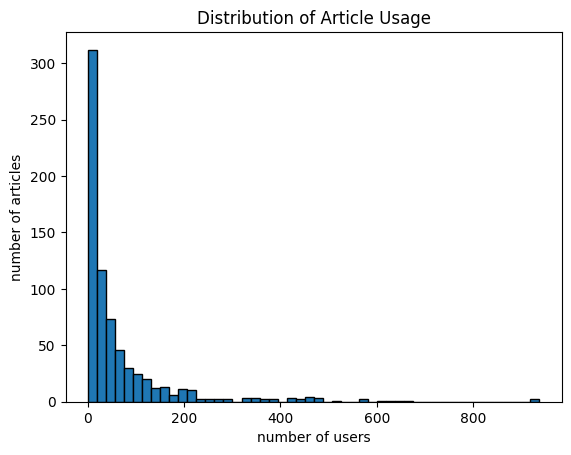

In [9]:
# Create a plot of the number of times each article was read
article_counts = df.groupby('article_id').count()['email']

plt.hist(article_counts, bins=50, edgecolor='black')
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [10]:
# Fill in the median and maximum number of user_article interactions below

median_val = stats['50%']
max_views_by_user = stats['max']

print(f"Median interactions: {median_val}")
print(f"Max interactions by one user: {max_views_by_user}")

Median interactions: 3.0
Max interactions by one user: 364.0


`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [11]:
unique_articles = df.article_id.nunique()

total_articles = df.article_id.nunique()

unique_users = df.email.nunique()

user_article_interactions = df.shape[0]

print(f"Unique Articles with interactions: {unique_articles}")
print(f"Total Articles on platform: {total_articles}")
print(f"Unique Users: {unique_users}")
print(f"Total Interactions: {user_article_interactions}")

Unique Articles with interactions: 714
Total Articles on platform: 714
Unique Users: 5149
Total Interactions: 45993


`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [12]:
most_viewed_article_id = article_counts.idxmax()

max_views = article_counts.max()

print(f'The most viewed article id : {most_viewed_article_id}')
print(f'The most views per article : {max_views}')

The most viewed article id : 1429
The most views per article : 937


In [13]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


In [14]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [15]:
def get_top_articles(n, df=df):
    '''
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    '''
    # Get the titles of the most viewed articles
    top_articles = list(df.title.value_counts().head(n).index)
    
    return top_articles 

def get_top_article_ids(n, df=df):
    '''
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) a list of the top 'n' article ids 
    '''
    # Count interactions per article_id and sort descending
    top_articles = df['article_id'].value_counts().iloc[:n].index.tolist()
    
    # Cast to strings to ensure consistency with the user_item matrix columns
    # but the assertion uses integers, so we cast to int(float()) to be safe
    top_articles = [int(float(aid)) for aid in top_articles]
    
    return top_articles

new_user_recs = get_top_article_ids(10)

In [16]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]


In [17]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [94]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df):
    '''
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    '''
    # 1. Drop duplicates to ensure we only have unique interactions
    # 2. Add a dummy column of 1s
    # 3. Pivot using unstack()
    user_item = df.groupby(['user_id', 'article_id'])['title'].max().unstack()
    
    # 4. Fill NaNs with 0 and convert any existing entries to 1
    user_item = user_item.notnull().astype(int)
    
    return user_item

In [95]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [96]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [97]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    '''
    INPUT:
    user_id - (int or str) a user identifier
    user_item - (pandas dataframe) matrix of users by articles
    include_similarity - (bool) whether to include similarity score
    
    OUTPUT:
    similar_users - (list) an ordered list of closest users
    '''
    # 1. Isolate the target user vector and reshape for sklearn (1, n_features)
    user_vector = user_item.loc[user_id].values.reshape(1, -1)
    
    # 2. Compute Cosine Similarity against all users
    # This returns a 2D array, so we flatten it to 1D
    sim_matrix = cosine_similarity(user_vector, user_item)
    similarities = pd.Series(sim_matrix.flatten(), index=user_item.index)

    # 3. Sort by similarity in descending order
    similarities = similarities.sort_values(ascending=False)

    # 4. Remove the own user's id from the list
    similarities = similarities.drop(user_id)

    # 5. Create the requested output formats
    if include_similarity:
        # Return list of lists: [[user_id, similarity_score], ...]
        return [[idx, sim] for idx, sim in similarities.items()]
    
    # Return just the ordered list of user IDs
    return list(similarities.index)

In [98]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 46, 4201, 824, 5034, 253, 5041, 2305, 136, 395]
The 5 most similar users to user 3933 are: [1, 4201, 46, 824, 253]
The 3 most similar users to user 46 are: [4201, 790, 5077]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [99]:

def get_article_names(article_ids, df=df):
    '''
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) the main interactions dataframe
    
    OUTPUT:
    article_names - (list) article titles associated with the ids
    '''
    # Convert input IDs to floats to match df.article_id dtype
    article_ids = [float(x) for x in article_ids]
    
    # Filter and get unique titles
    article_names = df[df['article_id'].isin(article_ids)]['title'].unique().tolist()
    
    return article_names

def get_user_articles(user_id, user_item=user_item):
    '''
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the ids
    '''
    # Find the row for the user and get column names where value is 1
    user_row = user_item.loc[user_id]
    # Keep as floats initially to match index, then convert to list
    article_ids = user_row[user_row == 1].index.tolist()
    
    # Get names using the helper function
    article_names = get_article_names(article_ids)
    
    # The test expects article_ids to be integers for comparison
    article_ids = [int(float(x)) for x in article_ids]
    
    return article_ids, article_names

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    '''
    INPUT:
    article_ids - (list) list of article ids
    user_item - (pandas dataframe) binary user-item matrix
    
    OUTPUT:
    ranked_article_unique_counts - (list) list of [article_id, count] pairs
    '''
    # Sum interactions for each article column
    counts = user_item[article_ids].sum(axis=0)
    
    # Create list of [id, count] and sort by count (descending)
    
    ranked_article_unique_counts = sorted([ [int(float(idx)), int(count)] for idx, count in counts.items()], 
                                          key=lambda x: x[1], reverse=True)
    
    return ranked_article_unique_counts

In [100]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [101]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [102]:
from sklearn.metrics.pairwise import cosine_similarity


def get_top_sorted_users(user_id, df=df, user_item=user_item):
    # 1. Similarity
    user_vec = user_item.loc[user_id].values.reshape(1, -1)
    sim_matrix = cosine_similarity(user_vec, user_item)
    
    # 2. THE COUNT (Crucial Step)
    # Ensure we count total interactions from the original df
    # This includes repeat views of the same article
    interacts_df = df.groupby('user_id')['article_id'].count().rename_axis('neighbor_id').reset_index(name='num_interactions')
    
    # 3. Create neighbors_df
    neighbors_df = pd.DataFrame({
        'neighbor_id': user_item.index,
        'similarity': sim_matrix.flatten()
    })
    
    # 4. Merge
    neighbors_df = pd.merge(neighbors_df, interacts_df, on='neighbor_id', how='left')
    
    # 5. Filter own user
    neighbors_df = neighbors_df[neighbors_df.neighbor_id != user_id]
    
    # 6. The Sort
    # Similarity (Desc), Interactions (Desc), Neighbor_id (Asc)
    neighbors_df = neighbors_df.sort_values(by=['similarity', 'num_interactions', 'neighbor_id'], 
                                            ascending=[False, False, True])
    
    return neighbors_df.reset_index(drop=True)

def user_user_recs_part2(user_id, m=10):
    '''
    INPUT:
    user_id - (int)
    m - (int) number of recommendations
    
    OUTPUT:
    recs - (list) top m article ids
    rec_names - (list) top m article names
    '''
    # Get user's seen history
    seen_ids, _ = get_user_articles(user_id)
    
    # Get neighbors sorted by cosine similarity
    neighbors_df = get_top_sorted_users(user_id)
    
    # Global article popularity for tie-breaking article selection
    article_interactions = df.groupby('article_id').count()['user_id']
    
    recs = []
    
    for neighbor in neighbors_df['neighbor_id']:
        neighbor_ids, _ = get_user_articles(neighbor)
        
        # Articles neighbor has seen but user hasn't
        new_potential_recs = np.setdiff1d(neighbor_ids, seen_ids, assume_unique=True)
        
        # Sort these specific articles by global popularity
        # This fulfills the "Choose articles with the most total interactions" requirement
        sorted_new_recs = article_interactions.loc[new_potential_recs].sort_values(ascending=False).index.tolist()
        
        for art_id in sorted_new_recs:
            if art_id not in recs:
                recs.append(str(art_id))
            
            if len(recs) >= m:
                break
        
        if len(recs) >= m:
            break
            
    rec_names = get_article_names(recs)
    
    return recs, rec_names

In [103]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
['1293', '1162', '1185', '1165', '1293', '1185', '1165', '254', '1271', '1328']

The top 10 recommendations for user 20 are the following article names:
['classify tumors with machine learning', 'analyze energy consumption in buildings', 'income (2015): united states demographic measures', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'customer demographics and sales', 'apple, ibm add machine learning to partnership with watson-core ml coupling']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [104]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                45
   neighbor_id  similarity  num_interactions
0         5083    0.730297                 5
1         1890    0.577350                 5
2         1552    0.577350                 2
3         1372    0.471405                 4
4         2941    0.433013                 9
5         2360    0.408248                 5
6         1319    0.408248                 4
7         3586    0.408248                 4
8          348    0.408248                 3
9         2825    0.408248                 3
   neighbor_id  similarity  num_interactions
0         3870    0.986667               144
1          203    0.388909               160
2         4459    0.388909               158
3         3782    0.387585               363
4           40    0.384308                78
5         4932    0.384308                76
6           23    0.377647               364
7          242    0.375823               148
8         

In [105]:
### Tests with a dictionary of results
user1_most_sim = get_top_sorted_users(1).iloc[0]['neighbor_id']

user2_6th_sim = get_top_sorted_users(2).iloc[5]['neighbor_id']

user131_10th_sim = get_top_sorted_users(131).iloc[9]['neighbor_id']


In [106]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

Oops!  Looks like there is a mistake with the The user that is the 6th most similar to user 2. key in your dictionary.  The answer should be 3586.  Try again.


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

This is a classic example of the cold start problem. In which we do not have enough information about the customer to give personalized recomendations. In this case the 10 most popular artiles in general would serves as a good starting point to recommend. 

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [ ]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = [int(float(x)) for x in get_top_article_ids(10)]

# If you want to check it against the assertion manually:
print(new_user_recs)
print(f"Top 10 recommendations for new user 0: {new_user_recs}")


In [ ]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [ ]:
df.head()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
# unique articles
df_unique_articles = df['article_id'].nunique()
print(df_unique_articles)

In [ ]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
article_titles = df[['article_id', 'title']].drop_duplicates().sort_values('article_id')['title']

print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(article_titles)

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

In [ ]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [ ]:
n_clusters = 50  # Number of clusters
kmeans = KMeans(
    n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)

In [ ]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
unique_article_ids = df[['article_id', 'title']].drop_duplicates().sort_values('article_id')['article_id']

# zip the article_ids with the kmeans labels_
article_cluster_map = dict(zip(unique_article_ids, kmeans.labels_))

# 2. Map these clusters back to the main dataframe
df['title_cluster'] = df['article_id'].map(article_cluster_map)

In [ ]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

In [ ]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df with article_id and title_cluster columns
    
    OUTPUT:
    articles_in_cluster - (list) a list of article ids in the same cluster
    """
    # Get the cluster label for the provided article_id
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]
    
    # Get all article ids that belong to this cluster
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()
    
    # Remove the input article_id from the list so we don't recommend the same item
    if article_id in articles_in_cluster:
        articles_in_cluster.remove(article_id)
    
    return articles_in_cluster

In [ ]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) number of recommendations desired
    df - (pandas dataframe) the interactions dataframe
    
    OUTPUT:
    n_ranked_similar_articles - (list) top n article ids in the cluster ranked by popularity
    n_ranked_article_names - (list) top n article names
    """
    # Get the list of all other articles in the same cluster
    similar_article_ids = get_similar_articles(article_id, df)
    
    # Rank these articles based on unique user interaction counts
    ranked_tuples = get_ranked_article_unique_counts(similar_article_ids)
    
    # Extract just the IDs and the names for the top n
    n_ranked_similar_articles = [item[0] for item in ranked_tuples[:n]]
    n_ranked_article_names = get_article_names(n_ranked_similar_articles, df)
    
    return n_ranked_similar_articles, n_ranked_article_names  

In [ ]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

In [ ]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

**Write an explanation of your content based recommendation system here.**

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [ ]:
# quick look at the matrix
user_item.head()

`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

In [ ]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

It seems like the recall is starting to stagnate between 200 and 300 latent features, this would then be a good amount of latent features to use, since using more latent features only increase complexity but does not really add that much more predictive ability.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [ ]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD (200 x n_articles)
    user_item - (pandas dataframe) user-item matrix to map article IDs to indices
    include_similarity - (bool) whether to include similarity scores
    
    OUTPUT:
    article_ids - (list) ordered list of similar article IDs
    """
    # Find the index of the article_id in the user_item columns
    article_idx = np.where(user_item.columns == article_id)[0][0]
    
    # Calculate Cosine Similarity
    dot_prod_matrix = cosine_similarity(vt.T)
    
    # Get similarities for the specific article_idx
    sim_scores = dot_prod_matrix[article_idx]
    
    # Create an array of indices, sort them by similarity score (descending)
    sorted_indices = np.argsort(sim_scores)[::-1]
    sorted_indices = sorted_indices[sorted_indices != article_idx]
    
    # Map indices back to actual Article IDs
    article_ids = user_item.columns[sorted_indices].tolist()
    similarities = sim_scores[sorted_indices].tolist()
    
    if include_similarity:
        # Return [[id, score], ...]
        return [[int(article_ids[i]), similarities[i]] for i in range(len(article_ids))]
    
    # Return list of IDs
    return [int(aid) for aid in article_ids]

# Get 10 recommendations for article 4
svd_recs_4 = get_svd_similar_article_ids(4, v)[:10]
print(f"Top 10 SVD-similar articles for ID 4: {svd_recs_4}")

In [ ]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [ ]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

In [ ]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

In [ ]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

In [ ]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

To determine if these recommendations represent an improvement over the current methods, the most effective approach would be to conduct an A/B test by splitting the user base into a control group receiving the existing recommendations and a treatment group receiving the new recomendations. Success would be measured through specific engagement metrics like click-through rate, which indicates immediate interest, and mean reciprocal rank, which evaluates how high the relevant articles appear in the recommended list.

1. Rank-based recommendations are essential for new users with no history because they solve the cold-start problem by providing high-quality, popular content, though they suffer from a lack of personalization. 
2. For recently new users with a small amount of history, content-based filtering or SVD-driven similarity is a better lever because it can suggest articles within a specific topic or latent concept. 
3. Finally, for mature users with a deep history of clicks, collaborative filtering is the most powerful tool because it leverages the rich network of shared interests between users to find personal recommendations.

A superior long-term strategy would be a hybrid system that automatically shifts its weighting from popularity to content-similarity and eventually to full collaborative filtering as a user moves from their first visit to long-term engagement.

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [ ]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Recommendations_with_IBM.ipynb'])